# ClonalOrigin model and simulation-based inference

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils.torchutils import BoxUniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Observation data, simulator and prior

**Simulate observed data**

Set the true parameters as
* $\rho_s = 0.02$,
* $\delta = 300$,
* $\theta_s = 0.05$.

**Define prior distribution**

We set the prior to be uniform with range:
* $[0, 0.2]$ for $\rho_s$,
* $[1, 500]$ for $\delta$,
* $[0, 0.2]$ for $\theta_s$.

In [2]:
prior = BoxUniform(
    low=torch.tensor([0.0, 1.0, 0.0], device=torch_device),
    high=torch.tensor([0.2, 500.0, 0.2], device=torch_device), 
    device=torch_device
)

In [7]:
x_o_numpy = np.loadtxt('../data/ClonalOrigin/x_o_10000.csv', delimiter=",")
x_o = torch.tensor(x_o_numpy, device=torch_device)
x_o = x_o.float()
x_o

tensor([0.0046, 0.0048, 0.0024, 0.0000, 0.0020, 0.0015, 0.1452])

In [8]:
x_numpy = np.loadtxt('../data/ClonalOrigin/x_10000.csv', delimiter=",")
x = torch.tensor(x_numpy, device=torch_device)
x

tensor([[1.5349e-02, 1.0147e-02, 9.1995e-03,  ..., 1.0500e-02, 1.1500e-02,
         2.8983e-01],
        [3.3229e-02, 2.1511e-02, 1.6538e-02,  ..., 1.8000e-02, 1.6000e-02,
         3.7117e-01],
        [6.8982e-02, 4.6206e-02, 3.5037e-02,  ..., 8.6500e-02, 8.8000e-02,
         6.2050e-01],
        ...,
        [1.7830e-02, 9.2166e-03, 7.1809e-03,  ..., 9.5000e-03, 9.0000e-03,
         2.7350e-01],
        [1.3216e-03, 1.1728e-04, 1.3492e-04,  ..., 0.0000e+00, 0.0000e+00,
         5.7500e-02],
        [7.0891e-03, 6.6241e-03, 4.5952e-03,  ..., 2.5000e-03, 3.0000e-03,
         1.6050e-01]], dtype=torch.float64)

In [9]:
theta_numpy = np.loadtxt('../data/ClonalOrigin/theta_10000.csv', delimiter=",")
theta = torch.tensor(theta_numpy, device=torch_device)
theta

tensor([[1.4161e-01, 5.7735e+01, 1.0255e-01],
        [3.7611e-02, 1.2744e+02, 1.7380e-01],
        [1.5440e-01, 2.8293e+02, 1.7661e-01],
        ...,
        [1.0442e-01, 2.7950e+02, 6.4138e-02],
        [2.7635e-02, 1.8600e+02, 1.8453e-02],
        [2.0037e-02, 4.1082e+02, 5.1941e-02]], dtype=torch.float64)

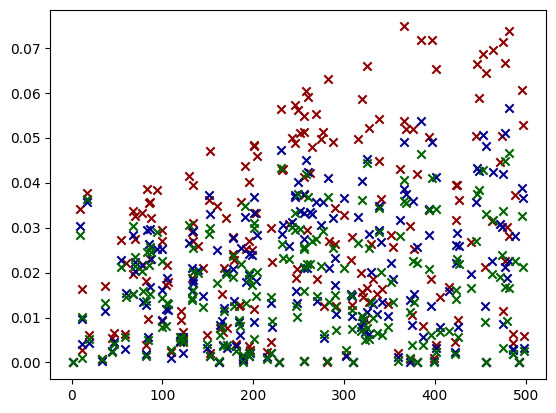

In [16]:
plt.scatter(x_mat[:, 1], summary_stats[:, 0], marker='x', color='darkred')
plt.scatter(x_mat[:, 1], summary_stats[:, 1], marker='x', color='darkblue')
plt.scatter(x_mat[:, 1], summary_stats[:, 2], marker='x', color='darkgreen')

# Display the plot
plt.show()

## Visualisation

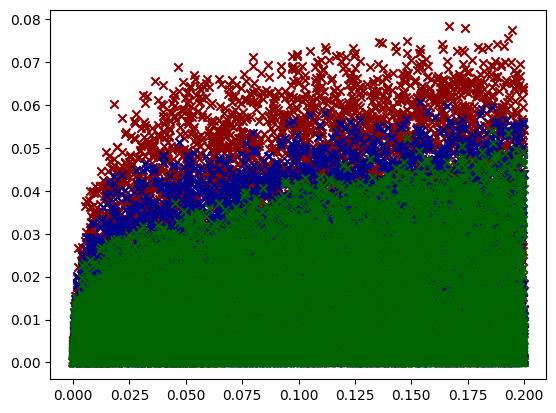

In [11]:
plt.scatter(theta_numpy[:, 0], x_numpy[:, 0], marker='x', color='darkred')
plt.scatter(theta_numpy[:, 0], x_numpy[:, 1], marker='x', color='darkblue')
plt.scatter(theta_numpy[:, 0], x_numpy[:, 2], marker='x', color='darkgreen')

# Display the plot
plt.show()

## NPE-C

In [2]:
simulation_budget = 5000
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

NameError: name 'prior' is not defined